# Retail Data Wrangling and Analytics

In [3]:
# Import modules 
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [4]:
#install psql "driver"
#!pip3 install psycopg2-binary

# Load CSV into Dataframe
Alternatively, the LGS IT team also dumped the transactional data into a [CSV file](https://raw.githubusercontent.com/jarviscanada/jarvis_data_eng_demo/feature/data/python_data_wrangling/data/online_retail_II.csv). However, the CSV header (column names) doesn't follow the snakecase or camelcase naming convention (e.g. `Customer ID` instead of `customer_id` or `CustomerID`). As a result, you will need to use Pandas to clean up the data before doing any analytics. In addition, unlike the PSQL scheme, CSV files do not have data types associated. Therefore, you will need to cast/convert certain columns into correct data types (e.g. DateTime, numbers, etc..)

**Data Preperation**

- Read the `data/online_retail_II.csv` file into a DataFrame
- Rename all columns to upper camelcase or snakecase
- Convert/cast all columns to the appropriate data types (e.g. datetime)

Read and printing `data/online_retail_II.csv`

In [5]:
retail_df = pd.read_csv("https://raw.githubusercontent.com/jarviscanada/jarvis_data_eng_demo/feature/data/python_data_wrangling/data/online_retail_II.csv")
retail_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Rename columns to snakecase

In [6]:
# Rename Columns To Snake Case 
retail_df.rename(
    columns={
        'Invoice' : 'invoice',
        'StockCode' : 'stock_code',
        'Description' : 'description',
        'Quantity' : 'quantity',
        'InvoiceDate' : 'invoice_date',
        'Price' : 'price',
        'Customer ID' : 'customer_id',
        'Country' : 'country'        
    },
    inplace=True
)

Typecast columns to the appropriate data types (e.g. datetime)

In [7]:
# Typecast
retail_df['customer_id'] = retail_df['customer_id'].astype('Int64')
retail_df['invoice_date'] = pd.to_datetime(retail_df['invoice_date'])

# Total Invoice Amount Distribution

Add 'amount' column for each item

In [8]:
# add amount column
retail_df['amount'] = retail_df['price'] * retail_df['quantity']

Show distribution for the total amount of each invoice

In [9]:
positive_amounts = retail_df[retail_df['amount'] > 0]
invoice_amount_df = (positive_amounts['amount']).groupby(retail_df['invoice']).sum()
def show_distribution(df):
    print(f"Minimum: {df.min()}")
    print(f"Mean: {df.mean():.2f}")
    print(f"Median: {df.median():.2f}")
    print(f"Mode: {df.mode().iloc[0]}")
    print(f"Maximum: {df.max()}")

show_distribution(invoice_amount_df)

Minimum: 0.19
Mean: 523.30
Median: 304.31
Mode: 15.0
Maximum: 168469.6


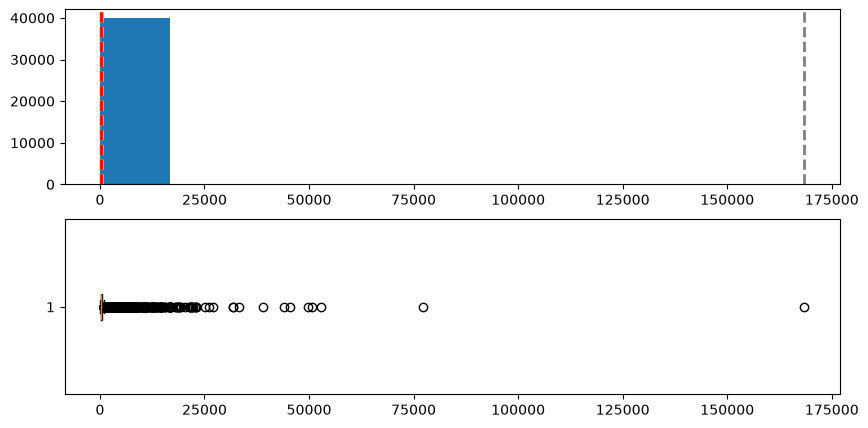

In [10]:
def show_figure(df):
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(10, 5)
    )
    minimum = df.min()
    mean = df.mean()
    median = df.median()
    mode = df.mode().iloc[0]
    maximum = df.max()

    ax1.hist(df, 10)
    ax1.axvline(minimum, color='grey', linestyle='--', linewidth=2)
    ax1.axvline(mode, color='yellow', linestyle='--', linewidth=2)
    ax1.axvline(mean, color='cyan', linestyle='--', linewidth=2)
    ax1.axvline(median, color='red', linestyle='--', linewidth=2)
    ax1.axvline(maximum, color='grey', linestyle='--', linewidth=2)
    
    ax2.boxplot(df, orientation='horizontal')

    plt.show()

show_figure(invoice_amount_df)

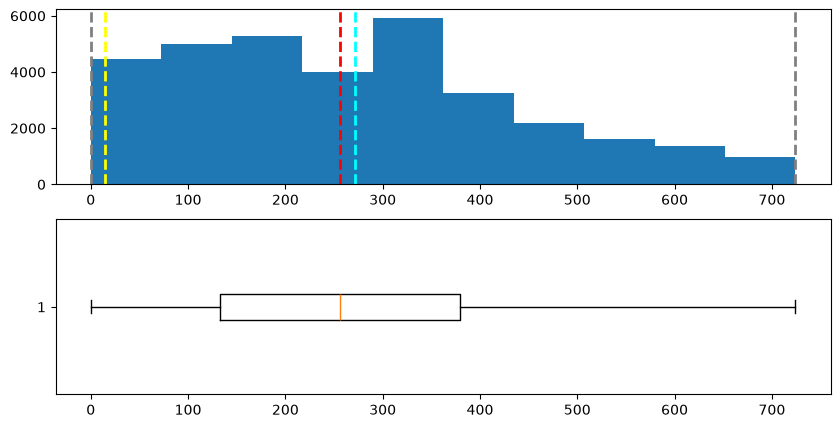

Minimum: 0.19
Mean: 271.68
Median: 256.24
Mode: 15.0
Maximum: 724.25


In [11]:
upper = invoice_amount_df.quantile(0.85)
invoice_amount_df_remove_outliers = invoice_amount_df[invoice_amount_df <= upper]
show_figure(invoice_amount_df_remove_outliers)
show_distribution(invoice_amount_df_remove_outliers)

# Monthly Placed and Canceled Orders

In [12]:
#add yyymm column
retail_df['yyyymm'] = retail_df['invoice_date'].dt.strftime('%Y%m')

<Axes: xlabel='yyyymm'>

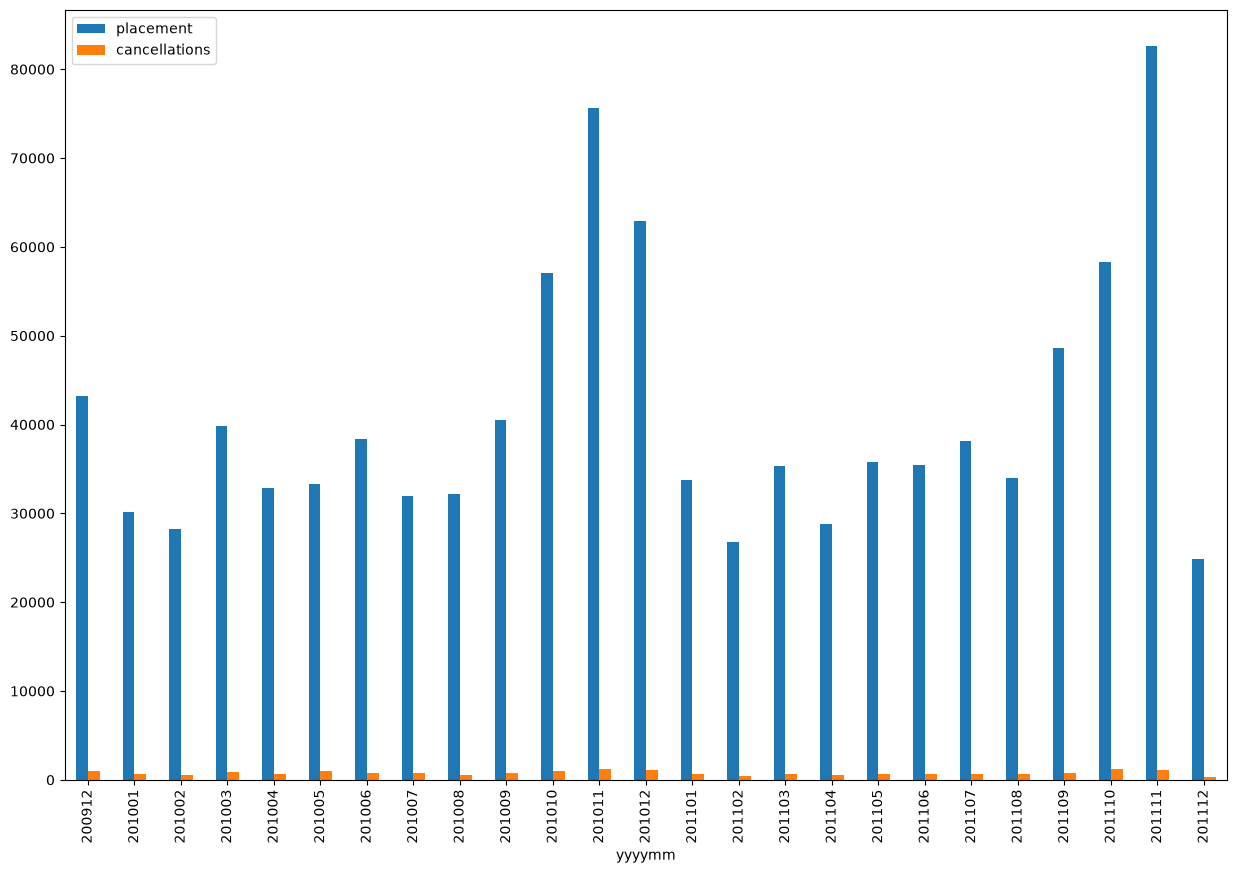

In [13]:
cancelled_orders_df = retail_df[retail_df['invoice'].str[0] == 'C'].groupby(retail_df['yyyymm'])['invoice'].count().reset_index()
cancelled_orders_df.rename(columns={'invoice' : 'cancellations'}, inplace=True)
placed_orders_df = retail_df.groupby(retail_df['yyyymm'])['invoice'].count().reset_index()
placed_orders_df.rename(columns={'invoice' : 'placement'}, inplace=True)
merged_df = pd.merge(cancelled_orders_df, placed_orders_df, on='yyyymm')
merged_df['placement'] = merged_df['placement'] - 2 * merged_df['cancellations']
merged_df.plot(
    x = 'yyyymm', y=['placement', 'cancellations'], kind='bar', figsize=(15,10)
)

# Monthly Sales

In [14]:
monthly_sales_data = (
    retail_df.groupby('yyyymm')['amount']
    .sum()
    .reset_index()
)

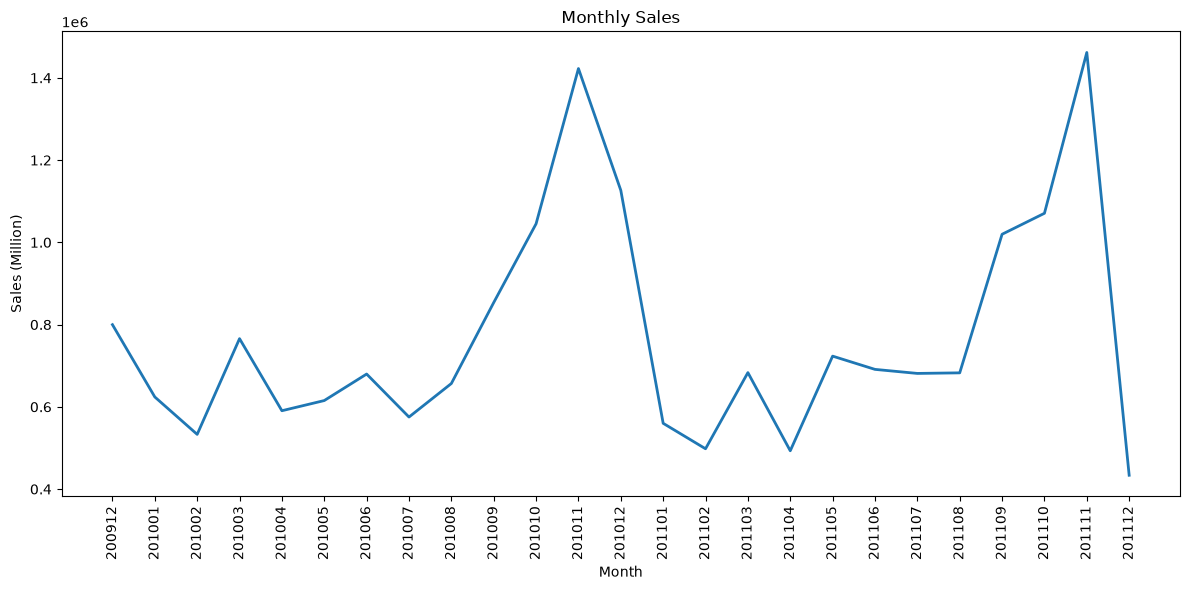

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales_data['yyyymm'].astype(str),
    monthly_sales_data['amount'],
    linewidth=2
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales (Million)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# Monthly Sales Growth


---
**Please remove this insturction cell after you are done with coding**

- Calculate monthly sales percentage growth data
- Plot a chart to show the growth percentage

![](https://i.imgur.com/J3btp8j.jpg)

---

In [16]:
monthly_sales_growth = monthly_sales_data.copy()
monthly_sales_growth['growth_pct'] = monthly_sales_growth['amount'].pct_change() * 100

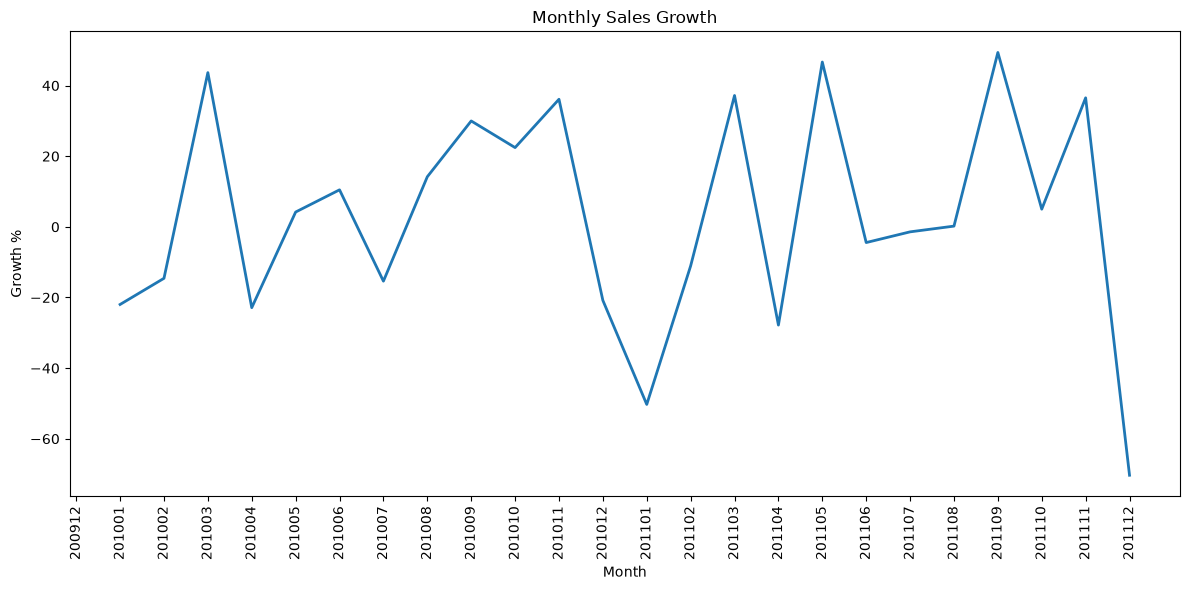

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales_growth['yyyymm'].astype(str),
    monthly_sales_growth['growth_pct'],
    linewidth=2
)

plt.title("Monthly Sales Growth")
plt.xlabel("Month")
plt.ylabel("Growth %")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# Monthly Active Users

In [18]:
monthly_active_users = retail_df.groupby('yyyymm')['customer_id'].nunique().reset_index()
monthly_active_users.rename(columns={'customer_id': 'active_users'}, inplace=True)

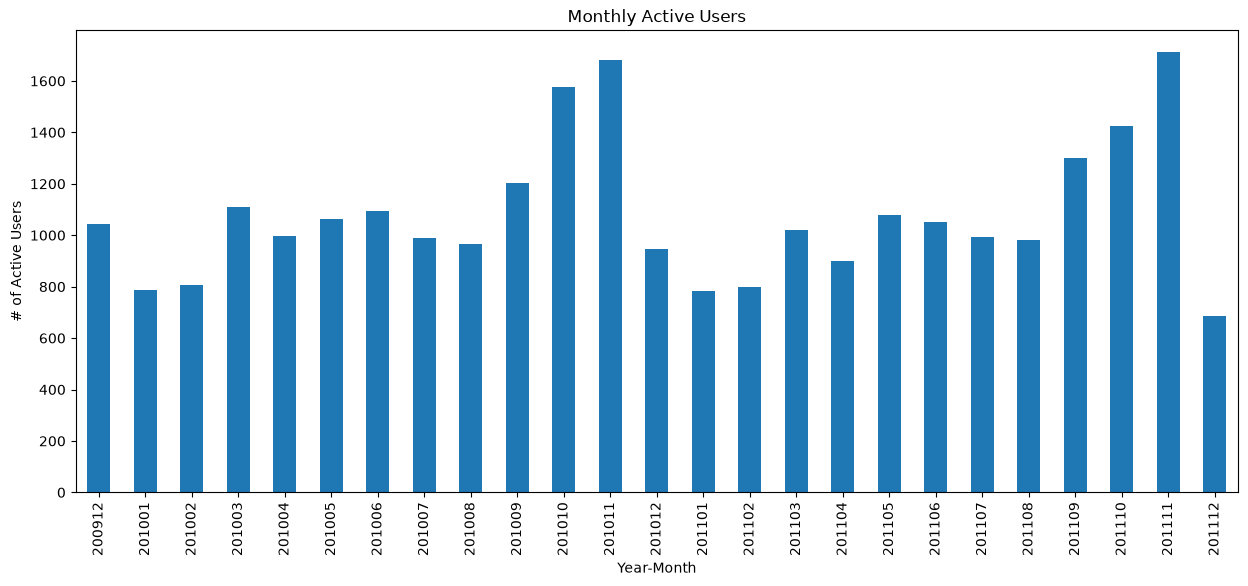

In [19]:
monthly_active_users.plot(
    x='yyyymm', y='active_users', kind='bar', figsize=(15, 6), legend=False,
    title='Monthly Active Users'
)
plt.ylabel('# of Active Users')
plt.xlabel('Year-Month')
plt.show()

# New and Existing Users



In [20]:
# Find each customer's first purchase year-month
first_purchase_df = retail_df.groupby('customer_id')['yyyymm'].min().reset_index()
first_purchase_df.rename(columns={'yyyymm': 'first_purchase_yyyymm'}, inplace=True)

# Join with transactional data to identify new vs existing users
user_activity_df = pd.merge(retail_df, first_purchase_df, on='customer_id')
user_activity_df['user_type'] = np.where(
    user_activity_df['yyyymm'] == user_activity_df['first_purchase_yyyymm'],
    'new', 'existing'
)

new_existing_df = (
    user_activity_df.groupby(['yyyymm', 'user_type'])['customer_id']
    .nunique()
    .reset_index()
    .pivot(index='yyyymm', columns='user_type', values='customer_id')
    .fillna(0)
)

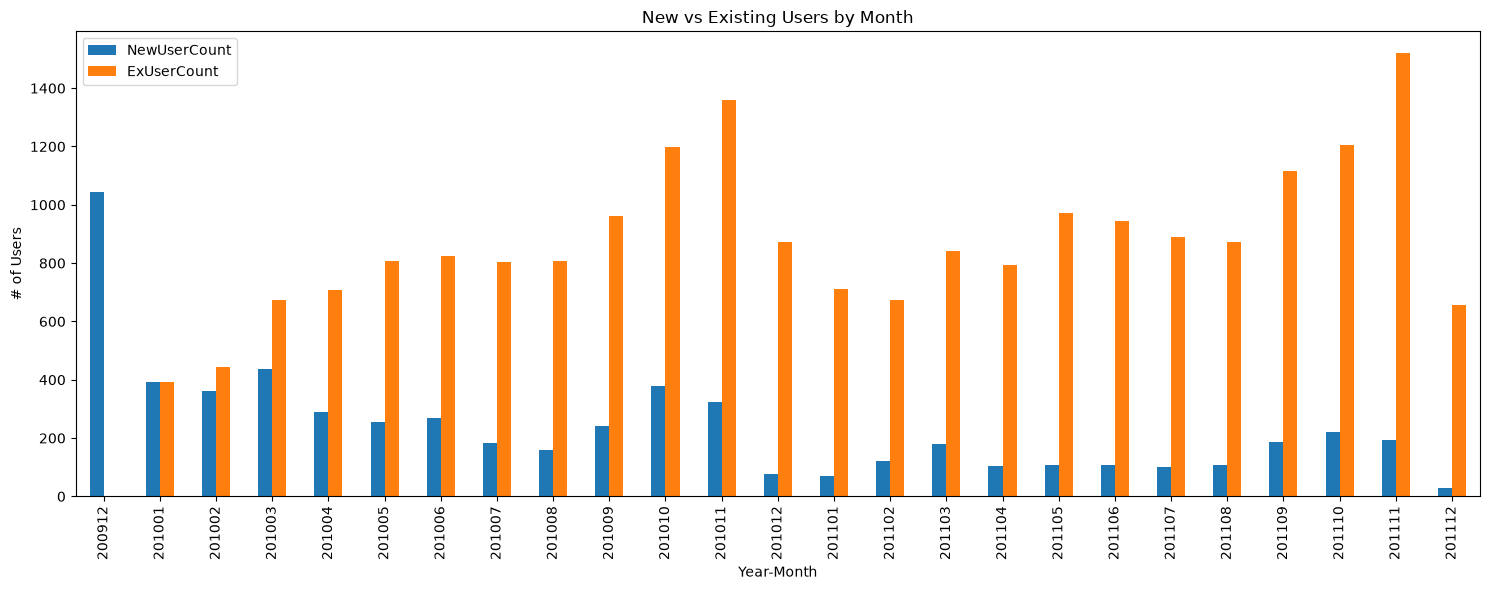

In [24]:
new_existing_df = new_existing_df.rename(
    columns={
        'new': 'NewUserCount',
        'existing': 'ExUserCount'
    }
)
new_existing_df.plot(
    y=['NewUserCount', 'ExUserCount'],
    kind='bar', figsize=(15, 6),
    title='New vs Existing Users by Month'
)

plt.title('New vs Existing Users by Month')
plt.xlabel('Year-Month')
plt.ylabel('# of Users')

plt.legend(
    title='',
    loc='upper left'
)

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Finding RFM

RFM is a method used for analyzing customer value. It is commonly used in database marketing and direct marketing and has received particular attention in the retail and professional services industries. ([wikipedia](https://en.wikipedia.org/wiki/RFM_(market_research)))

Optional Reading: [Making Your Database Pay Off Using Recency Frequency and Monetary Analysis](http://www.dbmarketing.com/2010/03/making-your-database-pay-off-using-recency-frequency-and-monetary-analysis/)


RFM stands for three dimensions:

- Recency – How recently did the customer purchase?

- Frequency – How often do they purchase?

- Monetary Value – How much do they spend?

Note: To simplify the problem, let's keep all placed and canceled orders.


**Sample RFM table**

![](https://i.imgur.com/sXFIg6u.jpg)

In [25]:
# Use one day after the last invoice date as the snapshot/reference date
snapshot_date = retail_df['invoice_date'].max() + pd.Timedelta(days=1)

rfm_df = retail_df.dropna(subset=['customer_id']).groupby('customer_id').agg(
    recency=('invoice_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('invoice', 'nunique'),
    monetary=('amount', 'sum')
).reset_index()

rfm_df

,customer_id,recency,frequency,monetary
0,12346,326,17,-64.68
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,5,4404.54
4,12350,310,1,334.40
...,...,...,...,...
5937,18283,4,22,2736.65
5938,18284,430,2,436.68
5939,18285,661,1,427.00
5940,18286,477,3,1188.43


In [26]:
rfm_df[['recency', 'frequency', 'monetary']].describe()

,recency,frequency,monetary
count,5942.000000,5942.000000,5942.000000
mean,202.908617,7.552339,2801.799459
std,211.857936,15.972262,13973.922553
min,1.000000,1.000000,-25111.090000
25%,25.000000,2.000000,325.097500
50%,96.000000,4.000000,843.970000
75%,381.000000,8.000000,2182.005000
max,739.000000,510.000000,598215.220000


# RFM Segmentation

---
**Please remove this insturction cell after you are done with coding**
RFM segmentation categorizes your customers into different segments, according to their interactions with your website, which will allow you to subsequently approach these groups in the most effective way. In this article, we will show you how to make an RFM segmentation based on an RFM score combining all three RFM parameters together and allowing you to divide your customers into 11 different segments. 

- [RFM Segmentation business cases](https://docs.exponea.com/docs/rfm-segmentation-business-use)

- [RFM Segmentation Guide](https://docs.exponea.com/docs/rfm-segmentation-business-use)

As you can see, computing RFM segmentation requires extensive domain knowledge in marketing which is out of the scope in this project. In practice, you will work with BA/DA to figure out how to compute RFM segments. To simplify this project, a [sample RFM segmentation Notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) is provided. You are responsible to understand everything from that Notebook and then integrate it into yours. 

- Download the [sample notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) and import to your Jupyter Notebook or VSCode
- Run the notebook and understand all cells
- Read the remark section at the end of the notebook. You will need this information when writing the README file
- Integrate the RFM segmentation calculation into your notebook

---

In [27]:
# Score each RFM dimension into quartiles (1 = worst, 4 = best)
# Recency is reversed since a SMALLER number of days since last purchase is better
rfm_df['R'] = pd.qcut(rfm_df['recency'], q=4, labels=range(4, 0, -1)).astype(int)
rfm_df['F'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=4, labels=range(1, 5)).astype(int)
rfm_df['M'] = pd.qcut(rfm_df['monetary'], q=4, labels=range(1, 5)).astype(int)

rfm_df['RFM_Score'] = rfm_df['R'].astype(str) + rfm_df['F'].astype(str) + rfm_df['M'].astype(str)

# Map the Recency/Frequency combination to a customer segment
segment_map = {
    '44': 'Champions',
    '43': 'Loyal Customers', '34': 'Loyal Customers',
    '42': 'Potential Loyalists', '33': 'Potential Loyalists', '24': 'Potential Loyalists',
    '41': 'New Customers',
    '32': 'Promising', '31': 'Promising',
    '23': 'Need Attention', '22': 'Need Attention',
    '21': 'About to Sleep', '12': 'About to Sleep',
    '13': 'At Risk', '14': 'At Risk',
    '11': 'Hibernating'
}
rfm_df['Segment'] = (rfm_df['R'].astype(str) + rfm_df['F'].astype(str)).map(segment_map)

rfm_df[['customer_id', 'recency', 'frequency', 'monetary', 'RFM_Score', 'Segment']].head(10)

,customer_id,recency,frequency,monetary,RFM_Score,Segment
0,12346,326,17,-64.68,241,Potential Loyalists
1,12347,2,8,5633.32,434,Loyal Customers
2,12348,75,5,2019.40,333,Potential Loyalists
3,12349,19,5,4404.54,434,Loyal Customers
4,12350,310,1,334.40,212,About to Sleep
5,12351,375,1,300.93,211,About to Sleep
6,12352,36,13,1889.21,343,Loyal Customers
7,12353,204,2,406.76,212,About to Sleep
8,12354,232,1,1079.40,213,About to Sleep
9,12355,214,2,947.61,213,About to Sleep


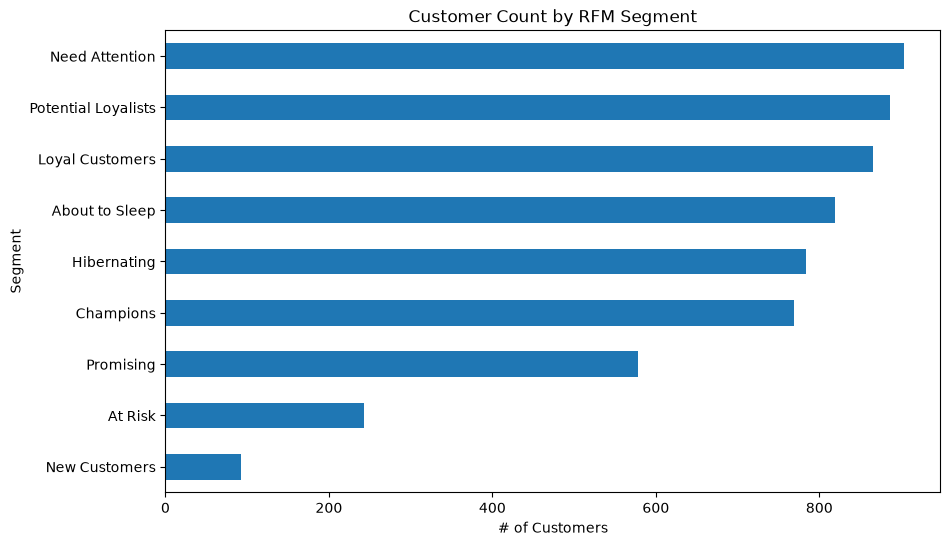

In [28]:
segment_counts = rfm_df['Segment'].value_counts().sort_values(ascending=True)
segment_counts.plot(
    kind='barh', figsize=(10, 6), title='Customer Count by RFM Segment'
)
plt.xlabel('# of Customers')
plt.ylabel('Segment')
plt.show()